<img src=https://upload.wikimedia.org/wikipedia/commons/6/68/Logo_universidad_icesi.svg width=300>

# Maestría en Inteligencia Artificial  
## Proyecto de Innovación III  
### Detección de pistolas y cuchillos en actos delictivos mediante visión computacional
---

**Integrantes:**  
- Johan Sebastian Bonilla  
- Edwin Gómez  

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sebastianb92/Weapon-Detection/blob/main/notebooks/02_inference.ipynb)

---

# 02 — Inferencia en imagen y video

Este notebook carga el modelo entrenado (`best.pt`) y permite:

1. **Inferencia en imagen estática** — detecta armas en una foto y muestra el resultado.  
2. **Inferencia en video (archivo)** — procesa un video `.mp4` frame a frame y genera un video anotado.  
3. **Inferencia en tiempo real (webcam)** — detecta armas en vivo desde la cámara (solo entorno local).  
4. **Descripción del evento con Gen AI** — envía el frame con detecciones a la API de Claude y genera una descripción en lenguaje natural del evento detectado.

> ⚠️ **Prerrequisito:** Debes haber ejecutado `01_eda.ipynb` y contar con el archivo `best.pt` en la ruta indicada.


## 0. Configuración de entorno

In [1]:
import os

# Detectar entorno
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    BASE_PATH = "/content"
else:
    BASE_PATH = os.getcwd()

print(f"Entorno: {'Google Colab' if IN_COLAB else 'Local'}")
print(f"BASE_PATH: {BASE_PATH}")


Entorno: Google Colab
BASE_PATH: /content


### Instalación de dependencias

En Colab se descargan automáticamente desde el repositorio.  
En local, asegúrate de haber ejecutado `pip install -r requirements.txt`.


In [2]:
if IN_COLAB:
    !wget -q https://raw.githubusercontent.com/sebastianb92/Weapon-Detection/main/requirements.txt -O requirements.txt
    !uv pip install -r requirements.txt
else:
    print("Entorno local — instala con: pip install -r requirements.txt")


Using Python 3.12.13 environment at: /usr
Resolved 66 packages in 3.05s
Prepared 2 packages in 249ms
Installed 2 packages in 49ms
 + ultralytics==8.4.46
 + ultralytics-thop==2.0.19


In [3]:
if IN_COLAB:
    !wget -q https://raw.githubusercontent.com/sebastianb92/Weapon-Detection/main/model/best.pt -O best.pt

### Imports

In [4]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display, Image as IPImage
from ultralytics import YOLO

print("Librerías cargadas correctamente.")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Librerías cargadas correctamente.


## 1. Configuración global

Ajusta las rutas y parámetros según tu entorno antes de ejecutar las secciones siguientes.


In [5]:
# ============================================================
# CONFIGURACIÓN — ajustado para Colab + wget
# ============================================================


# Ruta al modelo
if IN_COLAB:
    MODEL_PATH = Path("/content/best.pt")   # <- ahora está aquí
else:
    MODEL_PATH = Path(BASE_PATH) / "weapons_training/yolo11_weapons/weights/best.pt"

# Umbral de confianza
CONF_THRESHOLD = 0.5

# Clases
CLASS_NAMES = {0: "knife", 1: "pistol"}

# Colores (BGR)
CLASS_COLORS = {
    "knife":  (0, 165, 255),
    "pistol": (0, 0, 255),
}

# ============================================================
# CARGAR MODELO
# ============================================================

if not MODEL_PATH.exists():
    raise FileNotFoundError(
        f"No se encontró el modelo en: {MODEL_PATH}\n"
        "Verifica que el wget se ejecutó correctamente."
    )

model = YOLO(str(MODEL_PATH))

# Detectar device
if torch.cuda.is_available():
    DEVICE = 0
    print(f"GPU detectada: {torch.cuda.get_device_name(0)}")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = "mps"
    print("Apple Silicon GPU (MPS) detectada.")
else:
    DEVICE = "cpu"
    print("Usando CPU.")

print(f"Modelo cargado desde: {MODEL_PATH}")
print(f"Umbral de confianza: {CONF_THRESHOLD}")

Usando CPU.
Modelo cargado desde: /content/best.pt
Umbral de confianza: 0.5


## 2. Función de dibujo de detecciones

Función reutilizable que dibuja bounding boxes y etiquetas sobre cualquier frame.


In [6]:
def draw_detections(frame: np.ndarray, results) -> tuple[np.ndarray, list[dict]]:
    """
    Dibuja las detecciones sobre el frame y devuelve:
    - El frame anotado (BGR).
    - Lista de detecciones como dicts con keys: class_name, confidence, bbox.
    """
    detections = []
    annotated = frame.copy()

    boxes = results[0].boxes
    if boxes is None or len(boxes) == 0:
        return annotated, detections

    for box in boxes:
        conf = float(box.conf[0])
        if conf < CONF_THRESHOLD:
            continue

        cls_id = int(box.cls[0])
        cls_name = CLASS_NAMES.get(cls_id, f"clase_{cls_id}")
        color = CLASS_COLORS.get(cls_name, (255, 255, 255))

        x1, y1, x2, y2 = map(int, box.xyxy[0])

        # Bounding box
        cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)

        # Etiqueta con fondo
        label = f"{cls_name} {conf:.2f}"
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
        cv2.rectangle(annotated, (x1, y1 - th - 8), (x1 + tw + 4, y1), color, -1)
        cv2.putText(annotated, label, (x1 + 2, y1 - 4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

        detections.append({
            "class_name": cls_name,
            "confidence": round(conf, 3),
            "bbox": [x1, y1, x2, y2]
        })

    return annotated, detections


def show_frame(frame_bgr: np.ndarray, title: str = "Detección", figsize=(12, 7)):
    """Muestra un frame BGR en matplotlib (compatible Colab y local)."""
    rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=figsize)
    plt.imshow(rgb)
    plt.title(title, fontsize=13)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

print("Funciones de dibujo definidas.")


Funciones de dibujo definidas.


## 3. Inferencia en imagen estática

Proporciona la ruta de una imagen y el modelo detectará las armas presentes.


Imagen: armas (2161).jpg
Detecciones encontradas: 1
  • pistol — confianza: 0.669 — bbox: [2369, 1035, 2854, 1296]


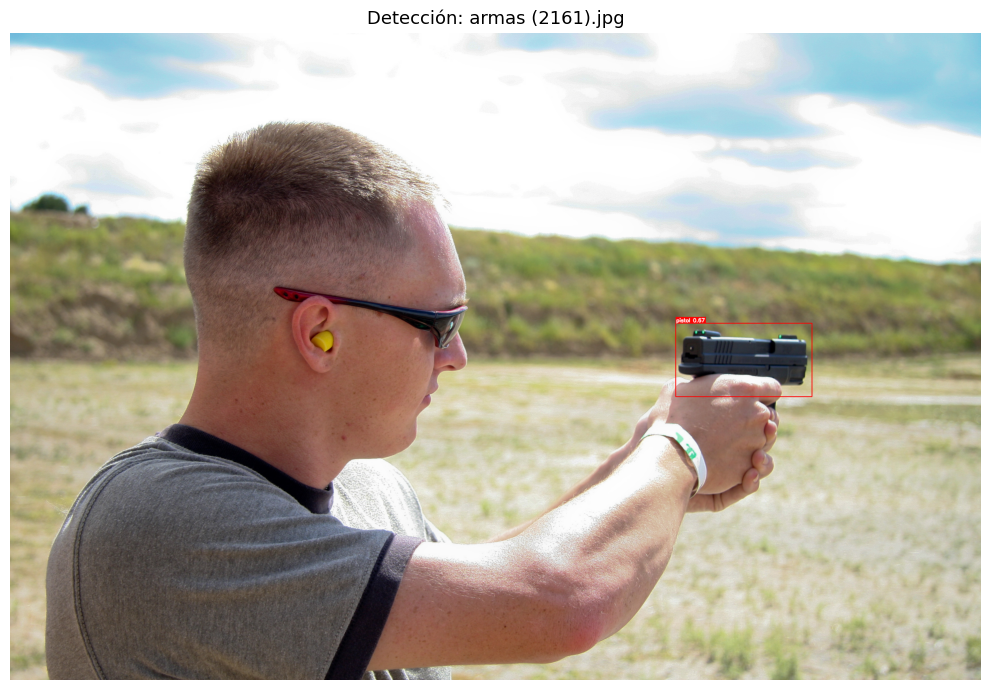

In [12]:
# ============================================================
# CONFIGURACIÓN — cambia la ruta a tu imagen
# ============================================================

if IN_COLAB:
    IMAGE_PATH = Path("/content/armas (2161).jpg")   # ← edita aquí
else:
    IMAGE_PATH = Path(BASE_PATH) / "/content/armas (2161).jpg"  # ← edita aquí



# ============================================================
# INFERENCIA
# ============================================================

if not IMAGE_PATH.exists():
    print(f"No se encontró la imagen: {IMAGE_PATH}")
    print("Cambia IMAGE_PATH a una ruta válida de imagen.")
else:
    frame = cv2.imread(str(IMAGE_PATH))
    results = model(frame, conf=CONF_THRESHOLD, device=DEVICE, verbose=False)

    annotated, detections = draw_detections(frame, results)

    print(f"Imagen: {IMAGE_PATH.name}")
    print(f"Detecciones encontradas: {len(detections)}")
    for d in detections:
        print(f"  • {d['class_name']} — confianza: {d['confidence']} — bbox: {d['bbox']}")

    show_frame(annotated, title=f"Detección: {IMAGE_PATH.name}")


## 4. Inferencia en video (archivo .mp4)

Procesa un video completo frame a frame. Genera un nuevo video con las detecciones anotadas.

> En Colab puedes subir el video desde el panel lateral o desde Google Drive.


In [8]:
# ============================================================
# CONFIGURACIÓN — cambia la ruta a tu video
# ============================================================

if IN_COLAB:
    VIDEO_INPUT  = Path("/content/mi_video.mp4")              # ← edita aquí
    VIDEO_OUTPUT = Path("/content/mi_video_detectado.mp4")
else:
    VIDEO_INPUT  = Path(BASE_PATH) / "mi_video.mp4"           # ← edita aquí
    VIDEO_OUTPUT = Path(BASE_PATH) / "mi_video_detectado.mp4"

# Procesar solo 1 de cada N frames (1 = todos, 2 = la mitad, etc.)
# Útil para acelerar el procesamiento en CPU
FRAME_SKIP = 1

# ============================================================
# PROCESAMIENTO
# ============================================================

if not VIDEO_INPUT.exists():
    print(f"No se encontró el video: {VIDEO_INPUT}")
    print("Cambia VIDEO_INPUT a una ruta válida.")
else:
    cap = cv2.VideoCapture(str(VIDEO_INPUT))

    fps    = cap.get(cv2.CAP_PROP_FPS)
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    print(f"Video: {VIDEO_INPUT.name}")
    print(f"Resolución: {width}x{height} | FPS: {fps:.1f} | Frames totales: {total}")
    print(f"Frame skip: {FRAME_SKIP} (procesando 1 de cada {FRAME_SKIP} frames)")

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    out    = cv2.VideoWriter(str(VIDEO_OUTPUT), fourcc, fps, (width, height))

    frame_idx        = 0
    total_detections = 0
    last_annotated   = None  # Guarda el último frame procesado para preview

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        if frame_idx % FRAME_SKIP == 0:
            results = model(frame, conf=CONF_THRESHOLD, device=DEVICE, verbose=False)
            annotated, detections = draw_detections(frame, results)
            total_detections += len(detections)
            last_annotated = annotated.copy()
        else:
            # Si se salta el frame, escribir el original sin anotar
            annotated = frame

        out.write(annotated)

        if frame_idx % 100 == 0:
            print(f"  Frame {frame_idx}/{total} procesado...")

        frame_idx += 1

    cap.release()
    out.release()

    print(f"\nVideo generado: {VIDEO_OUTPUT}")
    print(f"Frames procesados: {frame_idx}")
    print(f"Total de detecciones acumuladas: {total_detections}")

    # Mostrar último frame anotado como preview
    if last_annotated is not None:
        show_frame(last_annotated, title="Preview — último frame con detección")


No se encontró el video: /content/mi_video.mp4
Cambia VIDEO_INPUT a una ruta válida.


## 6. Descripción del evento con Gen AI (Gemini API)

Una vez detectadas las armas, esta sección envía el frame completo junto con las detecciones a la **API de Gemini** (visión) para generar una **descripción en lenguaje natural** del evento.

Esto es el componente de valor agregado del proyecto de maestría.

### ¿Cómo funciona?
1. Se toma el frame con las detecciones dibujadas.
2. Se convierte a objeto `PIL.Image` y se envía a `gemini-1.5-flash` junto con un prompt estructurado.
3. Gemini describe el evento: tipo de arma, posición en la escena, contexto estimado, nivel de riesgo.

> ⚠️ Necesitas configurar tu clave de API de Gemini (`GEMINI_API_KEY`).  
> En Colab puedes guardarla en los **Secrets** del panel lateral.



In [14]:
from google import genai
from google.genai import types
from google.colab import userdata
from PIL import Image
import io

# Cargar API Key desde Colab Secrets (o variable de entorno en local)
if IN_COLAB:
    try:
        GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")
        print("API Key cargada desde Colab Secrets.")
    except Exception:
        GEMINI_API_KEY = ""
        print("No se encontró GEMINI_API_KEY en Colab Secrets.")
        print("Ve a Secrets (panel lateral) y agrega tu clave con nombre: GEMINI_API_KEY")
else:
    GEMINI_API_KEY = os.environ.get("GEMINI_API_KEY", "")
    if not GEMINI_API_KEY:
        print("Define la variable de entorno GEMINI_API_KEY en tu sistema local.")
    else:
        print("API Key cargada desde variable de entorno.")

# Configurar cliente con el nuevo SDK google-genai
client = genai.Client(api_key=GEMINI_API_KEY)
GEMINI_MODEL = "gemini-2.0-flash"   # modelo actual recomendado
print(f"Cliente Gemini configurado. Modelo: {GEMINI_MODEL}")


API Key cargada desde Colab Secrets.
Cliente Gemini configurado. Modelo: gemini-2.0-flash


In [15]:
def frame_to_pil(frame_bgr) -> Image.Image:
    """Convierte un frame BGR de OpenCV a PIL.Image (RGB) para enviar a Gemini."""
    rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    return Image.fromarray(rgb)


def build_prompt(detections: list[dict]) -> str:
    """Construye el prompt enviado a Gemini con el contexto de las detecciones."""
    if not detections:
        return (
            "Analiza esta imagen de videovigilancia. "
            "No se detectaron armas automáticamente, pero describe brevemente la escena "
            "e indica si visualmente observas algo que pudiera representar un riesgo."
        )

    det_text = "\n".join(
        [f"  - {d['class_name']} (confianza: {d['confidence']:.0%}, "
         f"posición en imagen: [{d['bbox'][0]},{d['bbox'][1]}] → [{d['bbox'][2]},{d['bbox'][3]}])"
         for d in detections]
    )

    return f"""Eres un sistema de análisis de seguridad para videovigilancia inteligente.

Se han detectado automáticamente las siguientes armas en la imagen adjunta:
{det_text}

Con base en la imagen y en las detecciones, proporciona:
1. **Tipo de arma detectada** y descripción visual (color, tamaño aproximado, cómo se sostiene).
2. **Posición en la escena** (esquina, centro, fondo, etc.) y quién la porta si es visible.
3. **Contexto estimado** del entorno (interior, exterior, lugar público, iluminación).
4. **Nivel de riesgo** (Bajo / Medio / Alto) con una justificación breve.
5. **Recomendación de acción** para el operador de seguridad.

Responde de forma clara, directa y en español. Máximo 150 palabras.
"""


def describe_event(frame_bgr, detections: list[dict]) -> str:
    """
    Envía el frame y las detecciones a la API de Gemini (google-genai SDK).
    Devuelve la descripción generada o un mensaje de error.
    """
    if not GEMINI_API_KEY:
        return "Error: GEMINI_API_KEY no configurada."

    pil_image = frame_to_pil(frame_bgr)
    prompt    = build_prompt(detections)

    try:
        response = client.models.generate_content(
            model=GEMINI_MODEL,
            contents=[pil_image, prompt],
        )
        return response.text
    except Exception as e:
        return f"Error al llamar a Gemini: {e}"


print("Funciones de Gen AI (Gemini) definidas.")


Funciones de Gen AI (Gemini) definidas.


### 6.1 Demo — descripción sobre una imagen

Usa la misma imagen de la sección 3 y genera la descripción del evento.


Detecciones: [{'class_name': 'pistol', 'confidence': 0.669, 'bbox': [2369, 1035, 2854, 1296]}]

Generando descripción con Gemini...

DESCRIPCIÓN DEL EVENTO
Error al llamar a Gemini: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_input_token_count, limit: 0, model: gemini-2.0-flash\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash\nPlease retry in 22.428149362s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapi

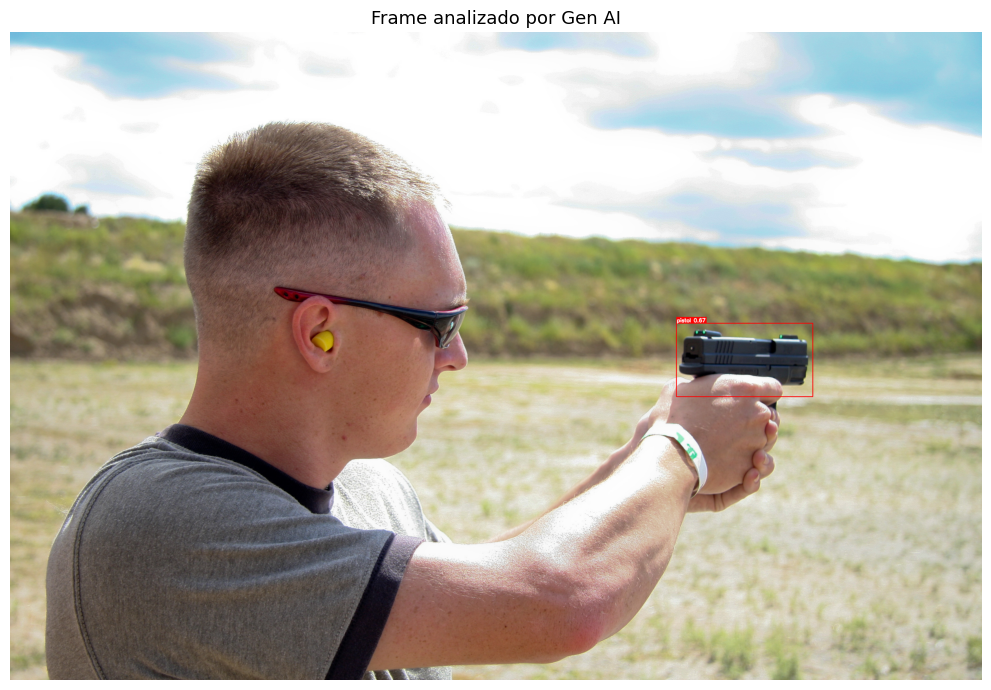

In [16]:
# Reutiliza IMAGE_PATH definida en la sección 3
# Si no la ejecutaste, define la ruta aquí:
# IMAGE_PATH = Path("/content/datasets/Valid/tu_imagen.jpg")

if not IMAGE_PATH.exists():
    print(f"No se encontró la imagen: {IMAGE_PATH}")
    print("Ejecuta primero la sección 3 o define IMAGE_PATH.")
else:
    frame = cv2.imread(str(IMAGE_PATH))
    results = model(frame, conf=CONF_THRESHOLD, device=DEVICE, verbose=False)
    annotated, detections = draw_detections(frame, results)

    print(f"Detecciones: {detections}")
    print("\nGenerando descripción con Gemini...\n")

    descripcion = describe_event(annotated, detections)

    print("=" * 60)
    print("DESCRIPCIÓN DEL EVENTO")
    print("=" * 60)
    print(descripcion)
    print("=" * 60)

    show_frame(annotated, title="Frame analizado por Gen AI")


### 6.2 Demo — descripción sobre un frame de video

Extrae un frame específico de un video y genera la descripción del evento.


In [ ]:
# Reutiliza VIDEO_INPUT definida en la sección 4
# Si no la ejecutaste, define la ruta aquí:
# VIDEO_INPUT = Path("/content/mi_video.mp4")

# Número de frame a analizar (0 = primer frame)
TARGET_FRAME = 30

if not VIDEO_INPUT.exists():
    print(f"No se encontró el video: {VIDEO_INPUT}")
    print("Ejecuta primero la sección 4 o define VIDEO_INPUT.")
else:
    cap = cv2.VideoCapture(str(VIDEO_INPUT))
    cap.set(cv2.CAP_PROP_POS_FRAMES, TARGET_FRAME)
    ret, frame = cap.read()
    cap.release()

    if not ret:
        print(f"No se pudo leer el frame {TARGET_FRAME}.")
    else:
        results = model(frame, conf=CONF_THRESHOLD, device=DEVICE, verbose=False)
        annotated, detections = draw_detections(frame, results)

        print(f"Frame #{TARGET_FRAME} extraído del video: {VIDEO_INPUT.name}")
        print(f"Detecciones: {detections}")
        print("\nGenerando descripción con Claude...\n")

        descripcion = describe_event(annotated, detections)

        print("=" * 60)
        print("DESCRIPCIÓN DEL EVENTO")
        print("=" * 60)
        print(descripcion)
        print("=" * 60)

        show_frame(annotated, title=f"Frame #{TARGET_FRAME} — analizado por Gen AI")


## 7. Pipeline completo — video con descripción Gen AI

Procesa un video completo y, cada vez que se detecta un arma, genera automáticamente una descripción del evento con Claude.

Las descripciones se guardan en un archivo `.json` con el timestamp del frame.

> ⚠️ Cada llamada a la API tiene un costo. Usa `GENAI_EVERY_N_FRAMES` para controlar cada cuántos frames con detección se llama a Claude.


In [ ]:
# ============================================================
# CONFIGURACIÓN
# ============================================================

if IN_COLAB:
    PIPELINE_INPUT  = Path("/content/mi_video.mp4")
    PIPELINE_OUTPUT = Path("/content/mi_video_pipeline.mp4")
    EVENTS_JSON     = Path("/content/eventos_detectados.json")
else:
    PIPELINE_INPUT  = Path(BASE_PATH) / "mi_video.mp4"
    PIPELINE_OUTPUT = Path(BASE_PATH) / "mi_video_pipeline.mp4"
    EVENTS_JSON     = Path(BASE_PATH) / "eventos_detectados.json"

# Llamar a Gen AI cada N frames donde se detecte un arma
# (1 = siempre que haya detección, 30 = aproximadamente cada 1 segundo a 30fps)
GENAI_EVERY_N_FRAMES = 30

# ============================================================
# PIPELINE
# ============================================================

if not PIPELINE_INPUT.exists():
    print(f"No se encontró el video: {PIPELINE_INPUT}")
else:
    cap    = cv2.VideoCapture(str(PIPELINE_INPUT))
    fps    = cap.get(cv2.CAP_PROP_FPS)
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    out    = cv2.VideoWriter(str(PIPELINE_OUTPUT), fourcc, fps, (width, height))

    events        = []
    frame_idx     = 0
    last_genai_at = -GENAI_EVERY_N_FRAMES  # Forzar primera llamada si hay detección

    print(f"Procesando: {PIPELINE_INPUT.name}")
    print(f"Total frames: {total} | FPS: {fps:.1f}")
    print("-" * 50)

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        results = model(frame, conf=CONF_THRESHOLD, device=DEVICE, verbose=False)
        annotated, detections = draw_detections(frame, results)

        # Si hay detección y corresponde llamar a Gen AI
        if detections and (frame_idx - last_genai_at) >= GENAI_EVERY_N_FRAMES:
            timestamp = frame_idx / fps if fps > 0 else 0
            print(f"  Frame {frame_idx} ({timestamp:.1f}s) — {len(detections)} detección(es) → llamando a Claude...")

            descripcion = describe_event(annotated, detections)
            last_genai_at = frame_idx

            event = {
                "frame":       frame_idx,
                "timestamp_s": round(timestamp, 2),
                "detections":  detections,
                "description": descripcion
            }
            events.append(event)

            print(f"    → {descripcion[:120]}...")

            # Mostrar descripción en el frame (primeras 2 líneas)
            lines = descripcion.split("\n")[:2]
            for i, line in enumerate(lines):
                cv2.putText(annotated, line[:80], (10, height - 50 + i * 20),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 1)

        out.write(annotated)
        frame_idx += 1

    cap.release()
    out.release()

    # Guardar eventos en JSON
    with open(EVENTS_JSON, "w", encoding="utf-8") as f:
        json.dump(events, f, ensure_ascii=False, indent=2)

    print("\n" + "=" * 50)
    print(f"Pipeline completado.")
    print(f"Video anotado: {PIPELINE_OUTPUT}")
    print(f"Eventos guardados: {EVENTS_JSON}")
    print(f"Total eventos con descripción: {len(events)}")
    print("=" * 50)


## 8. Referencias

**Ultralytics YOLO11**  
🔗 https://docs.ultralytics.com/es/models/yolo11/

**Anthropic API — Vision**  
🔗 https://docs.anthropic.com/en/docs/build-with-claude/vision

**OpenCV — VideoCapture**  
🔗 https://docs.opencv.org/4.x/d8/dfe/classcv_1_1VideoCapture.html
